In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("📚 Libraries loaded!")
print("🎯 Goal: Build forecasting + anomaly detection models")

📚 Libraries loaded!
🎯 Goal: Build forecasting + anomaly detection models


**laoding Data**

In [2]:
# Load hourly data
data_path = r"D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\data\processed_data.csv"
df = pd.read_csv(data_path, index_col='Datetime', parse_dates=True)

print(f"✅ Data loaded!")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

df.head()

✅ Data loaded!
Shape: (34589, 15)
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,Year,DayOfWeek,IsWeekend,Quarter,DayOfYear
Datetime,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,16.0,12,2006.0,5,1,4.0,350.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,16.0,12,2006.0,5,1,4.0,350.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,16.0,12,2006.0,5,1,4.0,350.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,16.0,12,2006.0,5,1,4.0,350.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,16.0,12,2006.0,5,1,4.0,350.0


**Feature Engineering for Time-Series**

In [3]:
# Create lag features (past consumption affects future)
print("🔧 Creating lag features...")

df['lag_1h'] = df['Global_active_power'].shift(1)   # 1 hour ago
df['lag_24h'] = df['Global_active_power'].shift(24) # Same time yesterday
df['lag_168h'] = df['Global_active_power'].shift(168) # Same time last week

# Rolling statistics
df['rolling_mean_24h'] = df['Global_active_power'].rolling(window=24).mean()
df['rolling_std_24h'] = df['Global_active_power'].rolling(window=24).std()
df['rolling_max_24h'] = df['Global_active_power'].rolling(window=24).max()
df['rolling_min_24h'] = df['Global_active_power'].rolling(window=24).min()

# Hour sin/cos encoding (cyclical feature)
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# Month sin/cos encoding
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Drop NaN rows (from lag/rolling)
df = df.dropna()

print(f"✅ Features created!")
print(f"New shape: {df.shape}")
print(f"Feature columns: {list(df.columns)}")

🔧 Creating lag features...
✅ Features created!
New shape: (34421, 26)
Feature columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Hour', 'Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend', 'Quarter', 'DayOfYear', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_max_24h', 'rolling_min_24h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


**Prepare Train/Test Split (Time-Series)**

In [4]:
# Time-series split (MUST be chronological!)
print("📊 Splitting data...")

# Use 80% for training, 20% for testing
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training: {len(train_df):,} hours ({train_df.index.min()} to {train_df.index.max()})")
print(f"Testing:  {len(test_df):,} hours ({test_df.index.min()} to {test_df.index.max()})")

# Define features and target
feature_cols = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month', 
                'lag_1h', 'lag_24h', 'lag_168h',
                'rolling_mean_24h', 'rolling_std_24h', 
                'rolling_max_24h', 'rolling_min_24h',
                'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

target_col = 'Global_active_power'

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nFeatures: {len(feature_cols)}")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

📊 Splitting data...
Training: 27,536 hours (2006-12-23 17:00:00 to 2010-02-13 00:00:00)
Testing:  6,885 hours (2010-02-13 01:00:00 to 2010-11-26 21:00:00)

Features: 18
Training samples: 27,536
Test samples: 6,885


## Baseline Model (Simple Moving Average)


In [5]:
# Baseline: Use yesterday's same hour as prediction
print("📈 BASELINE MODEL: Same Hour Yesterday")

baseline_pred = test_df['lag_24h'].values
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"RMSE: {baseline_rmse:.4f} kW")
print(f"MAE:  {baseline_mae:.4f} kW")
print(f"Mean consumption: {y_test.mean():.4f} kW")
print(f"RMSE as % of mean: {(baseline_rmse/y_test.mean()*100):.2f}%")

📈 BASELINE MODEL: Same Hour Yesterday
RMSE: 0.7794 kW
MAE:  0.5210 kW
Mean consumption: 0.9886 kW
RMSE as % of mean: 78.83%


## Random Forest Model

In [6]:
# Train Random Forest
print("\n🌲 RANDOM FOREST MODEL")
print("Training...")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Training complete!")

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"\nRMSE: {rf_rmse:.4f} kW ({(rf_rmse/y_test.mean()*100):.2f}% of mean)")
print(f"MAE:  {rf_mae:.4f} kW")
print(f"R²:   {rf_r2:.4f}")

# Improvement over baseline
improvement = ((baseline_rmse - rf_rmse) / baseline_rmse) * 100
print(f"\n🎯 Improvement over baseline: {improvement:.2f}%")


🌲 RANDOM FOREST MODEL
Training...
✅ Training complete!

RMSE: 0.2344 kW (23.71% of mean)
MAE:  0.1562 kW
R²:   0.8971

🎯 Improvement over baseline: 69.93%


**Feature Importance**


📊 TOP 10 MOST IMPORTANT FEATURES
             feature  importance
17    Sub_metering_3    0.494388
4             lag_1h    0.166884
16    Sub_metering_2    0.102006
15    Sub_metering_1    0.089254
9    rolling_max_24h    0.026442
12          hour_cos    0.022529
0               Hour    0.018017
5            lag_24h    0.015636
7   rolling_mean_24h    0.012574
6           lag_168h    0.011573


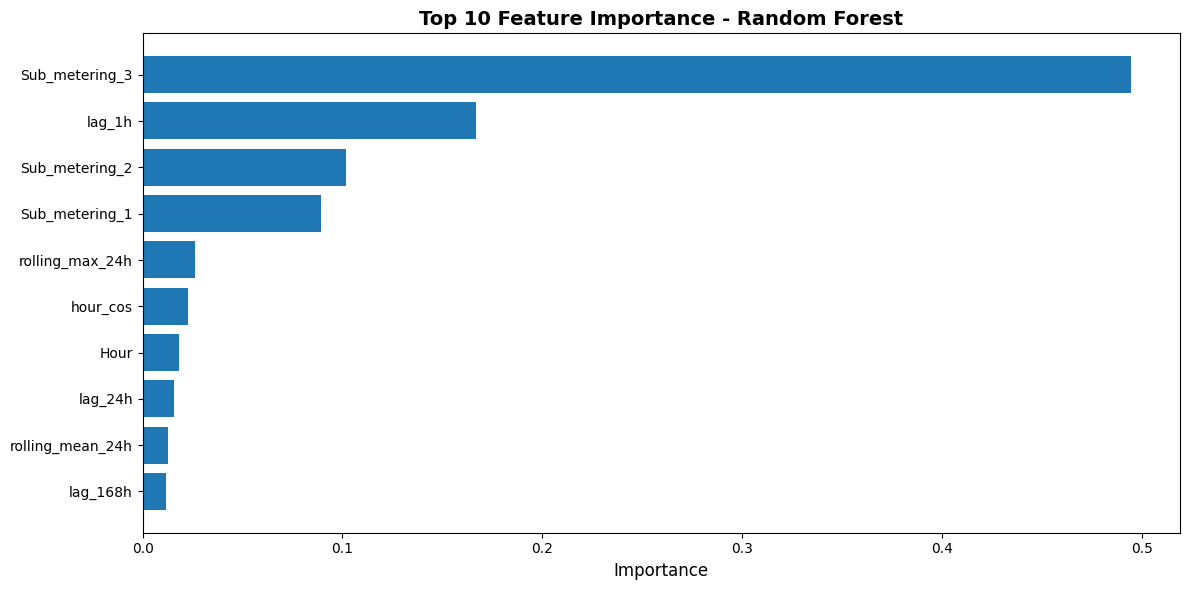

In [7]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Top 3 Features:

- Sub_metering_3 (AC/Heater): 49% importance → Dominates consumption!
- lag_1h (Last hour): 17% → Recent history matters
- Sub_metering_2 (Laundry): 10% → Second biggest factor

# Anomaly Detection Model

**Isolation Forest for Waste Detection**

In [9]:
print("\n🚨 ANOMALY DETECTION MODEL")
# Prepare data for anomaly detection
# Use only consumption-related features
anomaly_features = ['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
                   'Hour', 'DayOfWeek', 'IsWeekend']

X_anomaly = df[anomaly_features].copy()

# Train Isolation Forest
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    contamination=0.05,  # Expect 5% anomalies
    random_state=42,
    n_estimators=100,
    max_samples=256
)

iso_forest.fit(X_anomaly)
print("✅ Training complete!")

# Predict anomalies (-1 = anomaly, 1 = normal)
anomaly_labels = iso_forest.predict(X_anomaly)
anomaly_scores = iso_forest.score_samples(X_anomaly)

# Add to dataframe
df['is_anomaly'] = (anomaly_labels == -1).astype(int)
df['anomaly_score'] = anomaly_scores

# Statistics
n_anomalies = df['is_anomaly'].sum()
anomaly_pct = (n_anomalies / len(df)) * 100

print(f"\n📊 ANOMALY DETECTION RESULTS")
print(f"Total samples: {len(df):,}")
print(f"Anomalies detected: {n_anomalies:,} ({anomaly_pct:.2f}%)")
print(f"\nNormal consumption mean: {df[df['is_anomaly']==0]['Global_active_power'].mean():.2f} kW")
print(f"Anomaly consumption mean: {df[df['is_anomaly']==1]['Global_active_power'].mean():.2f} kW")
print(f"Difference: {df[df['is_anomaly']==1]['Global_active_power'].mean() - df[df['is_anomaly']==0]['Global_active_power'].mean():.2f} kW")


🚨 ANOMALY DETECTION MODEL
Training Isolation Forest...
✅ Training complete!

📊 ANOMALY DETECTION RESULTS
Total samples: 34,421
Anomalies detected: 1,721 (5.00%)

Normal consumption mean: 0.97 kW
Anomaly consumption mean: 3.17 kW
Difference: 2.19 kW


**Analyze Anomalies**


⏰ ANOMALY PATTERNS

Anomalies by hour:
Hour
19    207
20    180
21    153
12    125
18    118
dtype: int64

Anomalies by day:
Mon    171
Tue    194
Wed    190
Thu     90
Fri    127
Sat    408
Sun    541
dtype: int64


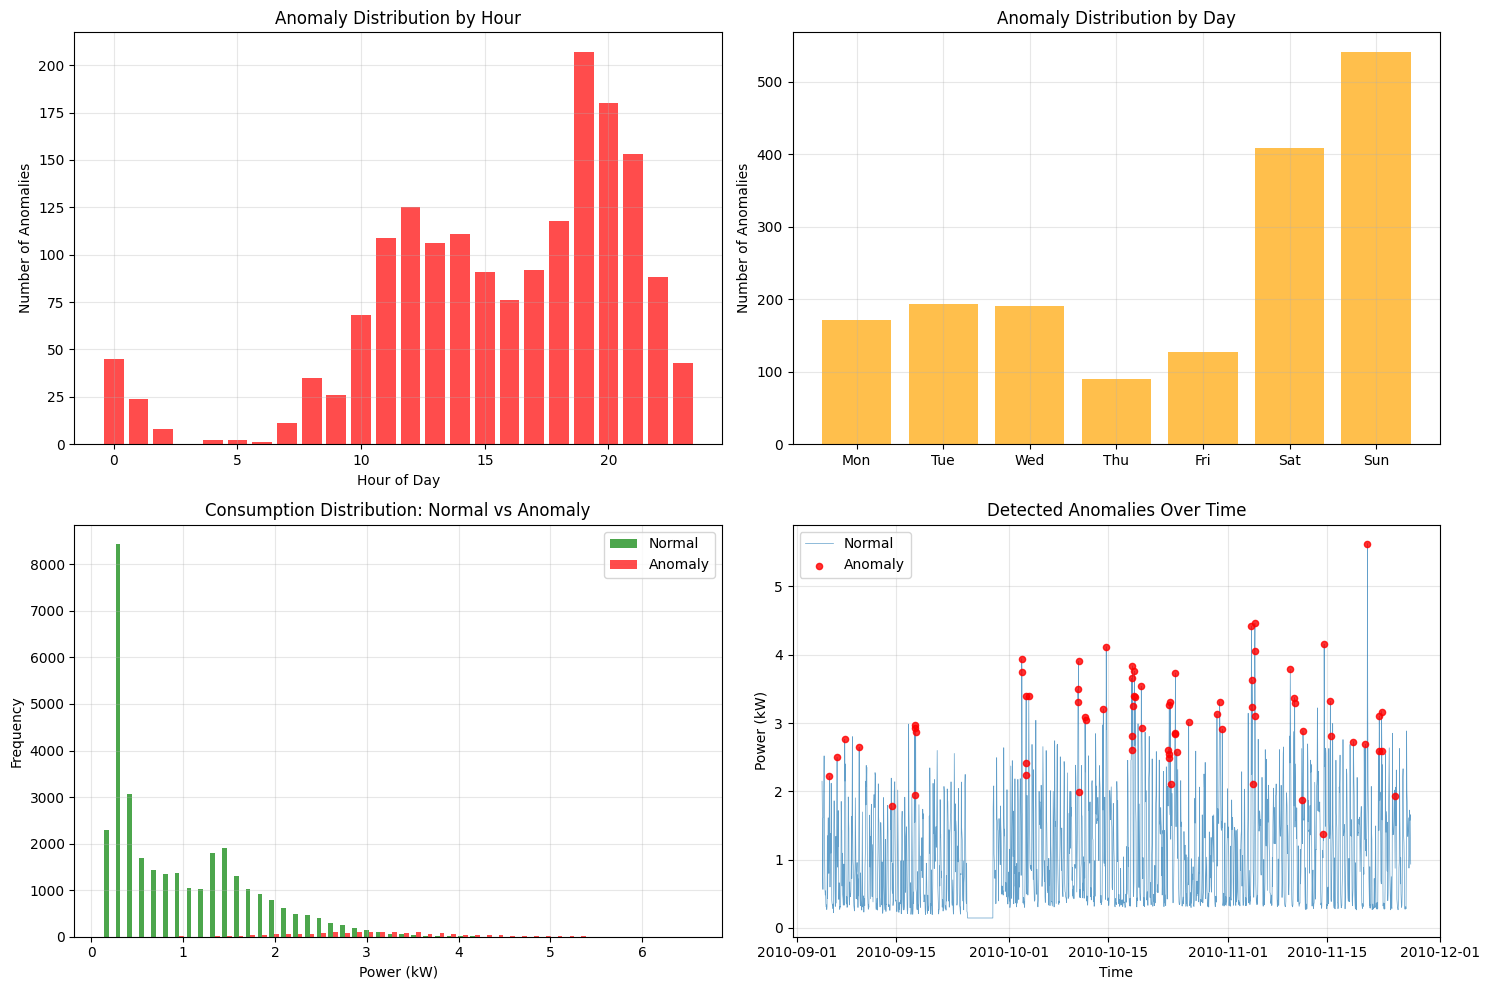

In [11]:
# When do anomalies occur?
print("\n⏰ ANOMALY PATTERNS")
print("="*60)

anomalies_df = df[df['is_anomaly'] == 1]

# By hour
anomaly_by_hour = anomalies_df.groupby('Hour').size()
print("\nAnomalies by hour:")
print(anomaly_by_hour.sort_values(ascending=False).head(5))

# By day of week
anomaly_by_day = anomalies_df.groupby('DayOfWeek').size()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
anomaly_by_day.index = days
print("\nAnomalies by day:")
print(anomaly_by_day)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Hour distribution
axes[0, 0].bar(range(24), [anomaly_by_hour.get(h, 0) for h in range(24)], color='red', alpha=0.7)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Anomalies')
axes[0, 0].set_title('Anomaly Distribution by Hour')
axes[0, 0].grid(True, alpha=0.3)

# Day distribution
axes[0, 1].bar(days, anomaly_by_day, color='orange', alpha=0.7)
axes[0, 1].set_ylabel('Number of Anomalies')
axes[0, 1].set_title('Anomaly Distribution by Day')
axes[0, 1].grid(True, alpha=0.3)

# Consumption comparison
normal_data = df[df['is_anomaly'] == 0]['Global_active_power']
anomaly_data = df[df['is_anomaly'] == 1]['Global_active_power']
axes[1, 0].hist([normal_data, anomaly_data], bins=50, label=['Normal', 'Anomaly'], alpha=0.7, color=['green', 'red'])
axes[1, 0].set_xlabel('Power (kW)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Consumption Distribution: Normal vs Anomaly')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Time series with anomalies highlighted
sample_period = df.iloc[-2000:]  # Last ~2000 hours for visibility
axes[1, 1].plot(sample_period.index, sample_period['Global_active_power'], linewidth=0.5, alpha=0.7, label='Normal')
anomaly_sample = sample_period[sample_period['is_anomaly'] == 1]
axes[1, 1].scatter(anomaly_sample.index, anomaly_sample['Global_active_power'], 
                   color='red', s=20, alpha=0.8, label='Anomaly', zorder=5)
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Power (kW)')
axes[1, 1].set_title('Detected Anomalies Over Time')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Night-time Waste Detection**

In [13]:
# Focus on night hours (0-6 AM) with high consumption = WASTE
print("\n🌙 NIGHT-TIME WASTE ANALYSIS")
print("="*60)

night_mask = (df['Hour'] >= 0) & (df['Hour'] < 6)
night_df = df[night_mask]

# Define waste threshold (75th percentile of night consumption)
waste_threshold = night_df['Global_active_power'].quantile(0.75)
night_waste = night_df[night_df['Global_active_power'] > waste_threshold]

print(f"Night hours analyzed: {len(night_df):,}")
print(f"Waste threshold: {waste_threshold:.2f} kW")
print(f"Waste events: {len(night_waste):,} ({len(night_waste)/len(night_df)*100:.2f}%)")
print(f"\nAverage waste consumption: {night_waste['Global_active_power'].mean():.2f} kW")
print(f"Normal night consumption: {night_df[night_df['Global_active_power'] <= waste_threshold]['Global_active_power'].mean():.2f} kW")

# Which sub-meter contributes most to night waste?
print(f"\n🔍 Sub-metering during waste events:")
print(f"Kitchen:    {night_waste['Sub_metering_1'].mean():.2f} Wh")
print(f"Laundry:    {night_waste['Sub_metering_2'].mean():.2f} Wh")
print(f"AC/Heater:  {night_waste['Sub_metering_3'].mean():.2f} Wh")


🌙 NIGHT-TIME WASTE ANALYSIS
Night hours analyzed: 8,604
Waste threshold: 0.49 kW
Waste events: 2,151 (25.00%)

Average waste consumption: 1.07 kW
Normal night consumption: 0.32 kW

🔍 Sub-metering during waste events:
Kitchen:    0.61 Wh
Laundry:    0.51 Wh
AC/Heater:  6.57 Wh


**Calculate Savings Potential**

In [14]:
print("\n SAVINGS CALCULATION")

# Cost assumptions (adjust for your region)
cost_per_kwh = 6.0  # ₹6 per kWh (typical campus rate)

# Total waste = anomalies + night waste
all_waste = df[df['is_anomaly'] == 1]
waste_consumption = all_waste['Global_active_power'].sum()
normal_equivalent = df['Global_active_power'].mean() * len(all_waste)
excess_consumption = waste_consumption - normal_equivalent

# Potential savings
daily_waste_hours = len(all_waste) / (len(df) / (len(df) / 24))  # Rough estimate
daily_savings_kwh = (excess_consumption / len(all_waste)) * 24
monthly_savings_kwh = daily_savings_kwh * 30
annual_savings_kwh = daily_savings_kwh * 365

daily_savings_cost = daily_savings_kwh * cost_per_kwh
monthly_savings_cost = monthly_savings_kwh * cost_per_kwh
annual_savings_cost = annual_savings_kwh * cost_per_kwh

print(f"⚡ Energy Savings Potential:")
print(f"   Daily:   {daily_savings_kwh:.2f} kWh")
print(f"   Monthly: {monthly_savings_kwh:.2f} kWh")
print(f"   Annual:  {annual_savings_kwh:.2f} kWh")

print(f"\n💵 Cost Savings Potential (@ ₹{cost_per_kwh}/kWh):")
print(f"   Daily:   ₹{daily_savings_cost:,.2f}")
print(f"   Monthly: ₹{monthly_savings_cost:,.2f}")
print(f"   Annual:  ₹{annual_savings_cost:,.2f}")

print(f"\n For a 1000-student campus:")
print(f"   Estimated annual savings: ₹{annual_savings_cost * 10:,.2f}")  # Scale up


 SAVINGS CALCULATION
⚡ Energy Savings Potential:
   Daily:   50.02 kWh
   Monthly: 1500.59 kWh
   Annual:  18257.12 kWh

💵 Cost Savings Potential (@ ₹6.0/kWh):
   Daily:   ₹300.12
   Monthly: ₹9,003.51
   Annual:  ₹109,542.72

 For a 1000-student campus:
   Estimated annual savings: ₹1,095,427.23


## Saving models

In [16]:
# Save models
print("\n💾 SAVING MODELS")

model_dir = r"D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\models"

# Save Random Forest
rf_path = f"{model_dir}/rf_forecaster.pkl"
joblib.dump(rf_model, rf_path)
print(f"✅ Random Forest saved: {rf_path}")

# Save Isolation Forest
iso_path = f"{model_dir}/isolation_forest_anomaly.pkl"
joblib.dump(iso_forest, iso_path)
print(f"✅ Isolation Forest saved: {iso_path}")

# Save feature columns
feature_info = {
    'feature_cols': feature_cols,
    'anomaly_features': anomaly_features,
    'target_col': target_col
}
import json
with open(f"{model_dir}/feature_info.json", 'w') as f:
    json.dump(feature_info, f)
print(f"✅ Feature info saved")

print("\n🎉 ALL MODELS SAVED!")


💾 SAVING MODELS
✅ Random Forest saved: D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\models/rf_forecaster.pkl
✅ Isolation Forest saved: D:\REHAAN\1. Ml Projects\6. Campus Energy Waste Detection\models/isolation_forest_anomaly.pkl
✅ Feature info saved

🎉 ALL MODELS SAVED!
